In [2]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
result_dir = Path("results_kmeans")
results = {}

for log_file in result_dir.glob("*.log"):
    name = log_file.stem  # filename without extension
    with open(log_file, "r") as f:
        content = f.read()
        match = re.search(r"Time for K-means: ([0-9]+) cycles", content)
        if match:
            results[name] = int(match.group(1))
        else:
            results[name] = None  # or np.nan if you prefer

results

{'avx2_double_k16_O0': 28529927920,
 'avx2_double_k16_O1': 3982068860,
 'avx2_double_k16_O2': 4111359720,
 'avx2_double_k16_O3': 2587785740,
 'avx2_double_k4_O0': 7624713140,
 'avx2_double_k4_O1': 1317303100,
 'avx2_double_k4_O2': 1239703960,
 'avx2_double_k4_O3': 1206489780,
 'avx2_double_k8_O0': 23084886160,
 'avx2_double_k8_O1': 5159216720,
 'avx2_double_k8_O2': 2553086940,
 'avx2_double_k8_O3': 2629434680,
 'avx2_float_k4_O0': 7597825260,
 'avx2_float_k4_O1': 1339640220,
 'avx2_float_k4_O2': 1216345180,
 'avx2_float_k4_O3': 1225662780,
 'avx2_float_k8_O0': 23050896520,
 'avx2_float_k8_O1': 5139282740,
 'avx2_float_k8_O2': 2577994340,
 'avx2_float_k8_O3': 2565433340,
 'sca_double_k16_O0': 22283783060,
 'sca_double_k16_O1': 6320706400,
 'sca_double_k16_O2': 4875694400,
 'sca_double_k16_O3': 3730696000,
 'sca_double_k4_O0': 4397304540,
 'sca_double_k4_O1': 1764207420,
 'sca_double_k4_O2': 1149324440,
 'sca_double_k4_O3': 985218100,
 'sca_double_k8_O0': 15246567320,
 'sca_double_k8_O1'

In [4]:
def get_metric(metric:str, content:str):
    matcher = f"{metric}[ ]*([0-9].[0-9]*)" 
    metric_search = re.search(matcher, content, re.IGNORECASE)
    if metric_search:
        result = float(metric_search.group(1))
        return result
    

In [5]:
df_dict = results
df_dict

{'avx2_double_k16_O0': 28529927920,
 'avx2_double_k16_O1': 3982068860,
 'avx2_double_k16_O2': 4111359720,
 'avx2_double_k16_O3': 2587785740,
 'avx2_double_k4_O0': 7624713140,
 'avx2_double_k4_O1': 1317303100,
 'avx2_double_k4_O2': 1239703960,
 'avx2_double_k4_O3': 1206489780,
 'avx2_double_k8_O0': 23084886160,
 'avx2_double_k8_O1': 5159216720,
 'avx2_double_k8_O2': 2553086940,
 'avx2_double_k8_O3': 2629434680,
 'avx2_float_k4_O0': 7597825260,
 'avx2_float_k4_O1': 1339640220,
 'avx2_float_k4_O2': 1216345180,
 'avx2_float_k4_O3': 1225662780,
 'avx2_float_k8_O0': 23050896520,
 'avx2_float_k8_O1': 5139282740,
 'avx2_float_k8_O2': 2577994340,
 'avx2_float_k8_O3': 2565433340,
 'sca_double_k16_O0': 22283783060,
 'sca_double_k16_O1': 6320706400,
 'sca_double_k16_O2': 4875694400,
 'sca_double_k16_O3': 3730696000,
 'sca_double_k4_O0': 4397304540,
 'sca_double_k4_O1': 1764207420,
 'sca_double_k4_O2': 1149324440,
 'sca_double_k4_O3': 985218100,
 'sca_double_k8_O0': 15246567320,
 'sca_double_k8_O1'

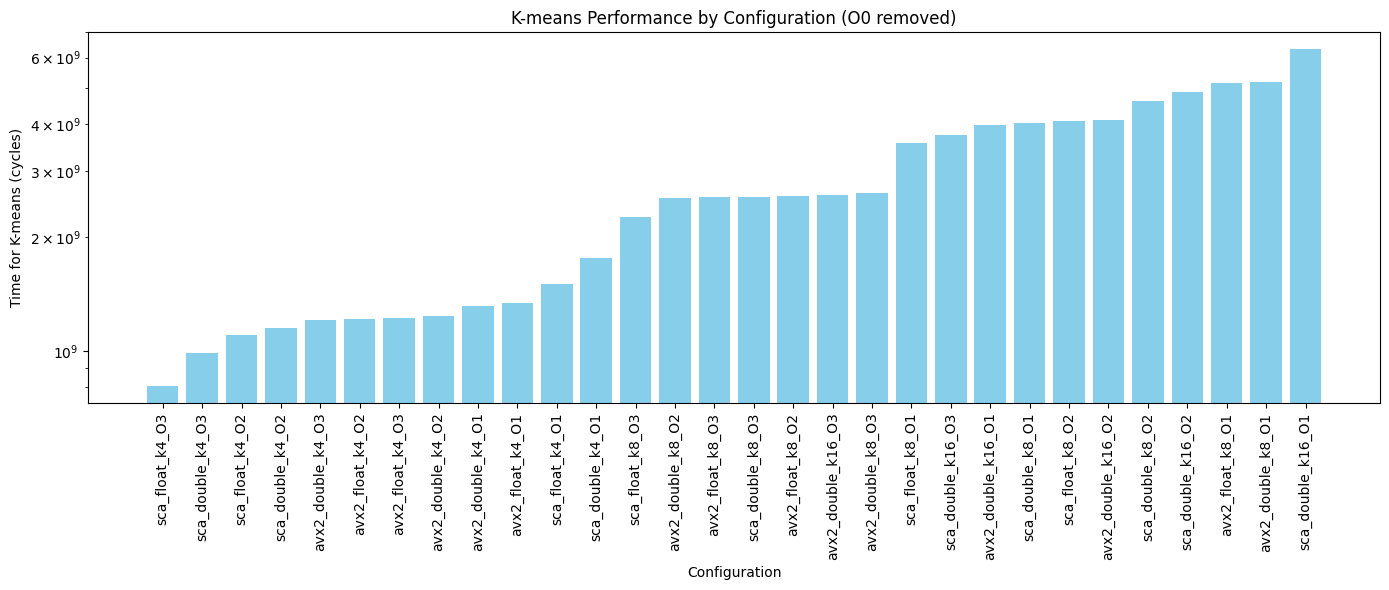

,Kmeans Time (cycles)
sca_float_k4_O3,806711520
sca_double_k4_O3,985218100
sca_float_k4_O2,1101244060
sca_double_k4_O2,1149324440
avx2_double_k4_O3,1206489780
avx2_float_k4_O2,1216345180
avx2_float_k4_O3,1225662780
avx2_double_k4_O2,1239703960
avx2_double_k4_O1,1317303100
avx2_float_k4_O1,1339640220


In [6]:
# Remove O0 examples from results and replot
def is_o0(name):
    return name.endswith('_O0')

# Filter out O0 results
o0_filtered_results = {k: v for k, v in results.items() if not is_o0(k)}
df = pd.DataFrame.from_dict(o0_filtered_results, orient='index', columns=['Kmeans Time (cycles)'])
df = df.sort_values(by='Kmeans Time (cycles)')

# Plotting
plt.figure(figsize=(14, 6))
plt.bar(df.index, df['Kmeans Time (cycles)'], color='skyblue')
plt.ylabel('Time for K-means (cycles)')
plt.xlabel('Configuration')
plt.title('K-means Performance by Configuration (O0 removed)')
plt.xticks(rotation=90)
plt.yscale('log')
plt.tight_layout()
plt.show()
df

In [7]:
datastr = df_dict
datastr

{'avx2_double_k16_O0': 28529927920,
 'avx2_double_k16_O1': 3982068860,
 'avx2_double_k16_O2': 4111359720,
 'avx2_double_k16_O3': 2587785740,
 'avx2_double_k4_O0': 7624713140,
 'avx2_double_k4_O1': 1317303100,
 'avx2_double_k4_O2': 1239703960,
 'avx2_double_k4_O3': 1206489780,
 'avx2_double_k8_O0': 23084886160,
 'avx2_double_k8_O1': 5159216720,
 'avx2_double_k8_O2': 2553086940,
 'avx2_double_k8_O3': 2629434680,
 'avx2_float_k4_O0': 7597825260,
 'avx2_float_k4_O1': 1339640220,
 'avx2_float_k4_O2': 1216345180,
 'avx2_float_k4_O3': 1225662780,
 'avx2_float_k8_O0': 23050896520,
 'avx2_float_k8_O1': 5139282740,
 'avx2_float_k8_O2': 2577994340,
 'avx2_float_k8_O3': 2565433340,
 'sca_double_k16_O0': 22283783060,
 'sca_double_k16_O1': 6320706400,
 'sca_double_k16_O2': 4875694400,
 'sca_double_k16_O3': 3730696000,
 'sca_double_k4_O0': 4397304540,
 'sca_double_k4_O1': 1764207420,
 'sca_double_k4_O2': 1149324440,
 'sca_double_k4_O3': 985218100,
 'sca_double_k8_O0': 15246567320,
 'sca_double_k8_O1'

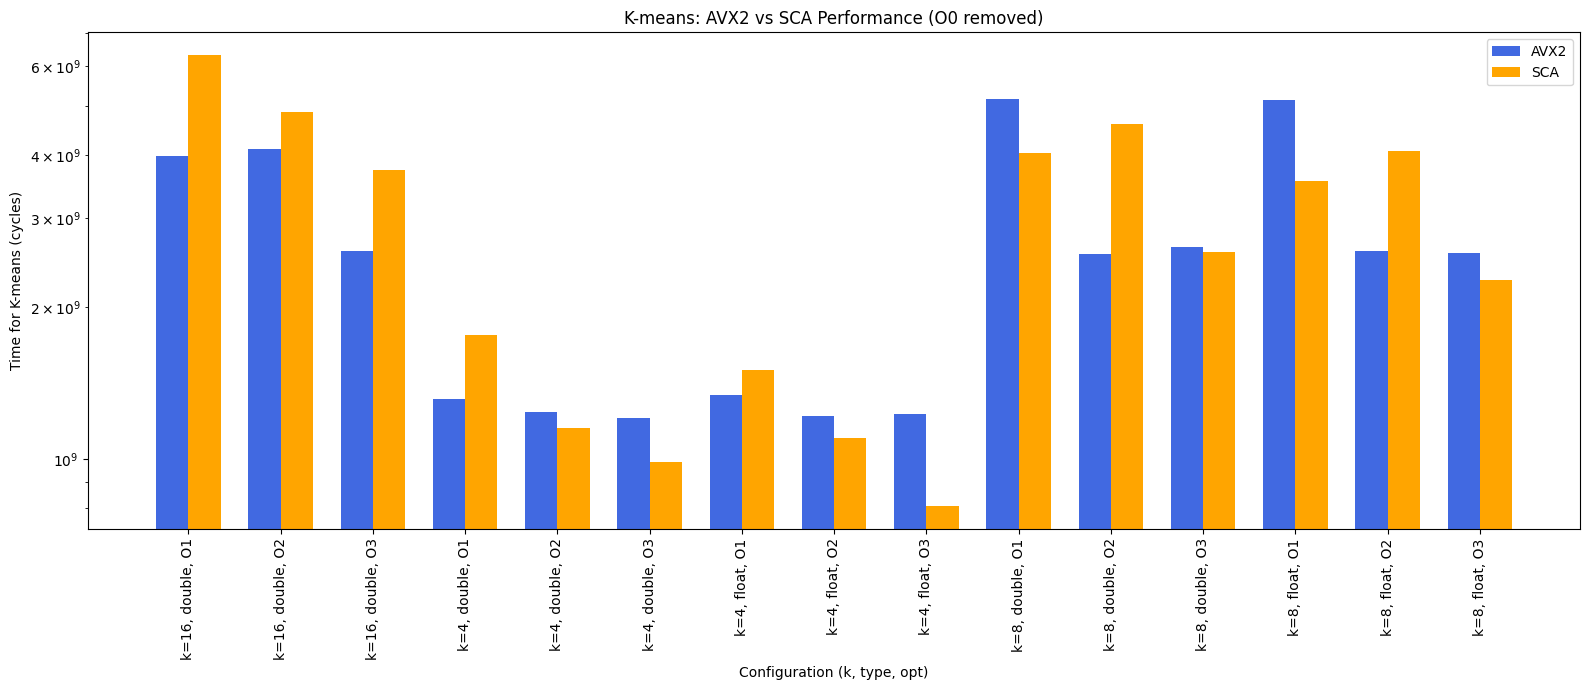

Method,AVX2,SCA
Group,,
"k=16, double, O1",3982068860,6320706400
"k=16, double, O2",4111359720,4875694400
"k=16, double, O3",2587785740,3730696000
"k=4, double, O1",1317303100,1764207420
"k=4, double, O2",1239703960,1149324440
"k=4, double, O3",1206489780,985218100
"k=4, float, O1",1339640220,1503843340
"k=4, float, O2",1216345180,1101244060
"k=4, float, O3",1225662780,806711520


In [8]:
# Grouped bar plot: AVX2 vs SCA
import re
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for grouped bar plot
# Extract method (avx2/sca), type (float/double), k, and opt level from the index
pattern = re.compile(r"(avx2|sca)_(float|double)_k(\d+)_O(\d+)")
groups = []
methods = []
values = []

for name, row in df.iterrows():
    m = pattern.match(name)
    if m:
        method, dtype, k, opt = m.groups()
        group = f"k={k}, {dtype}, O{opt}"
        groups.append(group)
        methods.append(method.upper())
        values.append(row['Kmeans Time (cycles)'])

# Create DataFrame for plotting
grouped_df = pd.DataFrame({
    'Group': groups,
    'Method': methods,
    'Time': values
})

pivot_df = grouped_df.pivot(index='Group', columns='Method', values='Time')
pivot_df = pivot_df.sort_index()

# Plot
group_labels = pivot_df.index
x = np.arange(len(group_labels))
bar_width = 0.35

plt.figure(figsize=(16, 7))
plt.bar(x - bar_width/2, pivot_df['AVX2'], width=bar_width, label='AVX2', color='royalblue')
plt.bar(x + bar_width/2, pivot_df['SCA'], width=bar_width, label='SCA', color='orange')
plt.ylabel('Time for K-means (cycles)')
plt.xlabel('Configuration (k, type, opt)')
plt.title('K-means: AVX2 vs SCA Performance (O0 removed)')
plt.xticks(x, group_labels, rotation=90)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()
pivot_df

In [9]:
# Export the pivot_df as a LaTeX table
latex_table = pivot_df.to_latex(float_format="%.0f", caption="K-means: AVX2 vs SCA Performance (O0 removed)", label="tab:kmeans_performance")
print(latex_table)

\begin{table}
\caption{K-means: AVX2 vs SCA Performance (O0 removed)}
\label{tab:kmeans_performance}
\begin{tabular}{lrr}
\toprule
Method & AVX2 & SCA \\
Group &  &  \\
\midrule
k=16, double, O1 & 3982068860 & 6320706400 \\
k=16, double, O2 & 4111359720 & 4875694400 \\
k=16, double, O3 & 2587785740 & 3730696000 \\
k=4, double, O1 & 1317303100 & 1764207420 \\
k=4, double, O2 & 1239703960 & 1149324440 \\
k=4, double, O3 & 1206489780 & 985218100 \\
k=4, float, O1 & 1339640220 & 1503843340 \\
k=4, float, O2 & 1216345180 & 1101244060 \\
k=4, float, O3 & 1225662780 & 806711520 \\
k=8, double, O1 & 5159216720 & 4032714960 \\
k=8, double, O2 & 2553086940 & 4615169760 \\
k=8, double, O3 & 2629434680 & 2566867520 \\
k=8, float, O1 & 5139282740 & 3558128320 \\
k=8, float, O2 & 2577994340 & 4082291540 \\
k=8, float, O3 & 2565433340 & 2262949680 \\
\bottomrule
\end{tabular}
\end{table}

